In [1]:
import marimo as mo
import os
import numpy as np
import pandas as pd
import scampi
from scampi.scampi import SCAMPI
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.simplefilter("ignore")

colors = sns.color_palette("tab20")

In [2]:
annotations = [
    "Walk very\nslow", 
    "Normal\nWalk", 
    "Nordic Walk", 
    "Run", 
    "Cycle", 
    "Run", 
    "Normal\nWalk", 
    "Soccer", 
    "Rope\nJump"
]

k_max = 100
window_size = 160

The 7-th motiflet appears between activities

<hr />

In [13]:
def find_dominant_window_sizes(X, offset=0.05):
    """Determine the Window-Size using dominant FFT-frequencies."""
    fourier = np.absolute(np.fft.fft(X))
    freqs = np.fft.fftfreq(X.shape[0], 1)
    plt.plot(fourier)
    plt.show()

    coefs = []
    window_sizes = []

    for coef, freq in zip(fourier, freqs):
        if coef and freq > 0:
            coefs.append(coef)
            window_sizes.append(1 / freq)

    coefs = np.array(coefs)
    window_sizes = np.asarray(window_sizes, dtype=np.int64)

    idx = np.argsort(coefs)[::-1]
    return next(
        (
            int(window_size / 2)
            for window_size in window_sizes[idx]
            if window_size in range(20, int(X.shape[0] * offset))
        ),
        window_sizes[idx[0]],
    )

def find_dominant_window_sizes2(X, offset=0.05, fs=100, f_min=1e-2):
    """Determine the Window-Size using dominant FFT-frequencies."""
    X = X - X.mean()
    fourier = np.fft.rfft(X)
    freqs = np.fft.rfftfreq(X.shape[0], d=1/fs)

    fourier = np.abs(fourier) / X.shape[0]             # Normalize amplitude
    fourier[1:-1] *= 2                          # Double non-DC, non-Nyquist bins

    plt.plot(freqs,fourier)
    # plt.xlim(0, fs / 2)
    plt.semilogx()

    mask = freqs >= f_min
    dominant_freq = freqs[mask][np.argmax(fourier[mask])]
    print("dominant frequency", dominant_freq, "corresponding window", fs/dominant_freq)
    plt.axvline(dominant_freq, color="red")
    ws = int(round(fs / dominant_freq))
    return ws

    
def load_dataset(dataset, selection=None):
    desc_filename = f"../datasets/{dataset}/desc.txt"
    desc_file = []

    with open(desc_filename, 'r') as file:
        for line in file.readlines(): desc_file.append(line.split(","))

    df = []

    for idx, row in enumerate(desc_file):
        if selection is not None and idx not in selection: continue
        (ts_name, window_size), change_points = row[:2], row[2:]
        if len(change_points) == 1 and change_points[0] == "\n": change_points = list()
        path = f'../datasets/{dataset}/'

        if os.path.exists(path + ts_name + ".txt"):
            ts = np.loadtxt(fname=path + ts_name + ".txt", dtype=np.float64)
        else:
            ts = np.load(file=path + "data.npz")[ts_name]

        df.append((ts_name, int(window_size), np.array([int(_) for _ in change_points]), ts))

    return pd.DataFrame.from_records(df, columns=["name", "window_size", "change_points", "time_series"])


def load_pamap():
    dataset="PAMAP"
    selection = [126, 127, 128] # Outdoor
    df_data = load_dataset(dataset)

    ts_name = df_data["name"].iloc[selection]
    ts = df_data.time_series.iloc[selection]
    cps = df_data.change_points.iloc[selection[0]]

    X = np.zeros((len(ts.values), len(ts.values[0])))
    for i, data in enumerate(ts.values):
        X[i] = data

    cps = np.concatenate([[0], cps, [X.shape[1]]])

    series = pd.DataFrame(data=X, index=ts_name)
    series.rename(index={'PAMAP_Outdoor_Subject8_IMU_Shoe_X-Acc': 'Shoe X-Acc', 
                         'PAMAP_Outdoor_Subject8_IMU_Shoe_Y-Acc': 'Shoe Z-Acc', 
                         'PAMAP_Outdoor_Subject8_IMU_Shoe_Z-Acc': 'Shoe Y-Acc'}, inplace=True)

    ## series = series.iloc[0, :]
    series = series.loc[["Shoe X-Acc"]]
    return series, cps

def zeucl(x, y):
    return np.linalg.norm(znorm(x) - znorm(y))

def extent(ts, w, motiflet):
    e = 0
    for i in motiflet:
      for j in motiflet:
          if j > i:
              e = max(e, zeucl(ts[i:i+w], ts[j:j+w]))
    return e



def znorm(x):
    return (x - x.mean()) / x.std()


def plot_topn(topn: SCAMPI, changepoints: np.array, annotations, fname=None):
    import matplotlib.gridspec as gridspec

    if topn.top_N <= 10:
        colors = sns.color_palette("tab10")
    else:
        colors = sns.color_palette("tab20")

    nrows = 1 + int(np.ceil(topn.top_N / 3))
    fig = plt.figure(figsize=(12, 2*nrows))

    # Create a GridSpec with 4 rows and 3 columns
    gs = gridspec.GridSpec(nrows, 3, figure=fig, hspace=0.4, wspace=0.3)

    # Top row: single plot spanning all 3 columns
    ax_top = fig.add_subplot(gs[0, :])
    # ax_top.set_title("Top Plot")
    ax_top.plot(topn.series, c="lightgray")
    for t in changepoints:
        ax_top.axvline(t, linestyle="dotted", c="lightgray")
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.set_ylim(-180, 200)
    for annotation, (b, e) in zip(annotations, 
                                  zip(changepoints[:-1], changepoints[1:])):
        x = (b + e) / 2
        ax_top.annotate(annotation, xy=(x, 100), fontsize=10, ha="center")

    # Bottom 3x3 grid occupying rows 1-3

    toplot = []
    for rank, elbows in enumerate(topn.elbow_points):
        if len(elbows) == 0:
            continue

        k = elbows[0]
        hsm = topn.motiflets[k][rank]
        d = extent(topn.series, topn.motif_length, hsm)
        # d = topn.dists[k, rank]

        toplot.append((d, hsm))
    toplot = sorted(toplot, key=lambda x: x[0])


    axes = []
    # for i, res in enumerate(topn.found_motiflets):
    for i, (d, hsm) in enumerate(toplot):
        if i >= len(colors):
            break
        row = i // 3 + 1
        col = i % 3
        # dists, motif_sets, elbow_points = res
        ax = fig.add_subplot(gs[row, col])
        ax.axis("off")
        mlabels = dict()
        for j, t in enumerate(hsm):
            idx = np.arange(t, min(t + topn.motif_length, len(topn.series)))
            subseq = topn.series[idx]
            ax.plot(znorm(subseq), c=colors[i], alpha=0.3)
            ax_top.plot(idx, subseq, c=colors[i])
            segment = np.searchsorted(changepoints, t, side="right") - 1
            segment = np.clip(segment, 0, len(annotations) - 1)
            l = annotations[segment]

            mlabels[l] = mlabels.get(l, 0) + 1
            # plt.plot(idx, subseq, c=colors[iteration])
        activity_label = "\n".join([
            "{} (x{})".format(k.replace("\n", " "), v)
            for k, v in mlabels.items()
        ])
        ax.set_title(f"{i+1:02d}. {activity_label} (e={d:.2f})",
                     fontsize=10, ha="left", loc="left", va="top")
        axes.append(ax)

    plt.tight_layout(pad=0)

    if fname is not None:
        plt.savefig(fname, dpi=300, bbox_inches="tight")

    plt.show()
    

In [4]:
series_df, changepoints = load_pamap()
series = series_df.values[0,:]
n = series.shape[0]

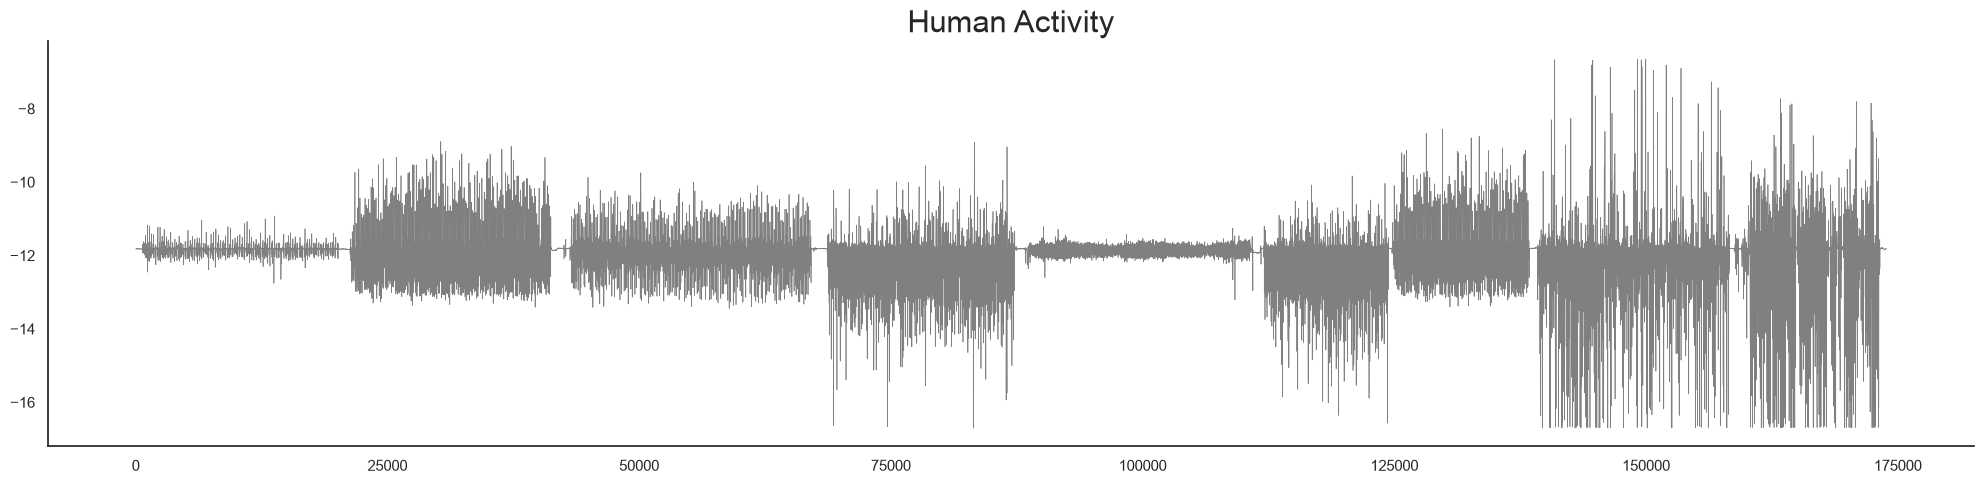

SCAMPI kwargs: delta=0.1, max_memory=2 GB, exact_refine=False, scampi_top_n_strategy=mask, unused={}


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 11.031451225
	Time for Test 12.725627505
masked timestamps: 8031


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 11.453991922
	Time for Test 9.251467497
masked timestamps: 28919
	Time for Build 10.215813822
	Time for Test 14.248616302
masked timestamps: 42581


...

	Time for Build 11.855882851
	Time for Test 13.896959428
masked timestamps: 92216


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 11.32800904
	Time for Test 13.592164325
masked timestamps: 97160
	Time for Build 5.662844759
	Time for Test 10.961953867
masked timestamps: 102046


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 5.192326254
	Time for Test 10.042264453
masked timestamps: 106835


In [5]:
k_max = 100
motif_length = 200 
top_N = 12

scampi_topn = SCAMPI(
    "Human Activity",
    series,
    n_jobs=-1,
    backend="scampi",
    verbose=False,
    scampi_delta=0.1
)
fig, ax = scampi_topn.plot_dataset()

dists, candidates, elbow_points = scampi_topn.fit_k_elbow(
    k_max=k_max,
    motif_length=motif_length,
    top_N=top_N,
    scampi_top_n_strategy="mask",
    filter=True,
    plot_elbows=False,
    plot_motifs_as_grid=False,
)

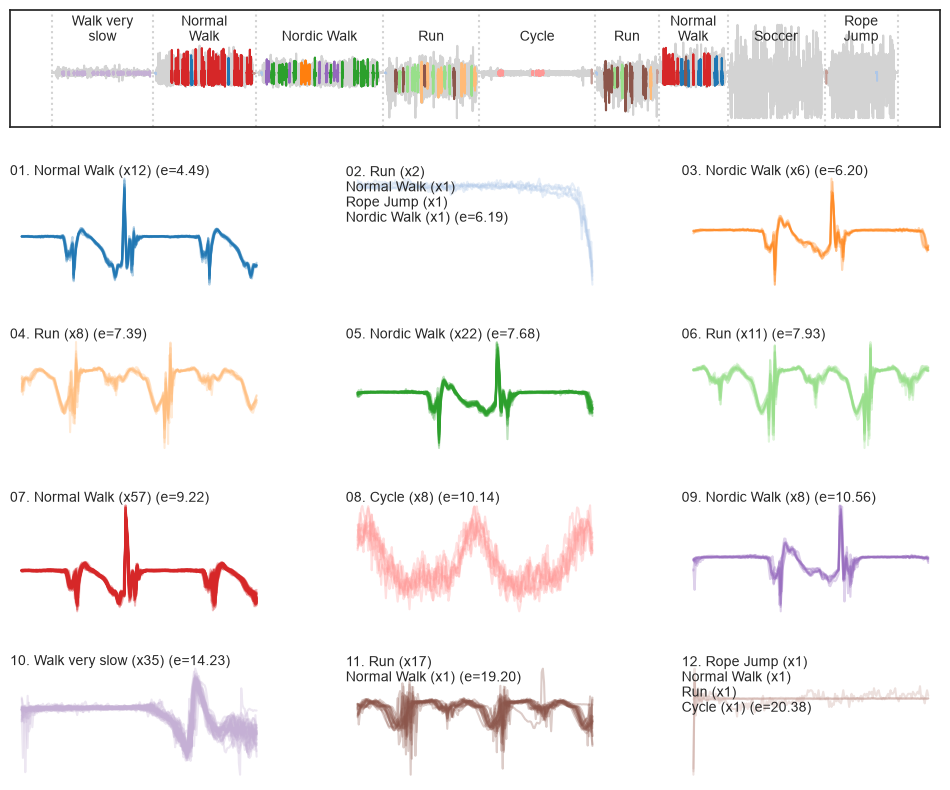

In [14]:
plot_topn(
    scampi_topn, changepoints, annotations
)

In [7]:
scampi_topn.elbow_points

[array([12, 58, 89]),
 array([57, 65]),
 array([22, 34, 37, 77]),
 array([35, 38, 96]),
 array([ 4, 11, 15, 25, 32, 45]),
 array([11, 15, 24, 27, 32, 47, 74]),
 array([ 6, 15, 19, 21, 25, 87]),
 array([ 8, 35, 46]),
 array([18, 20, 79]),
 array([ 8, 17, 23, 29, 66]),
 array([ 5,  8, 12, 19, 24, 33, 41]),
 array([ 8, 12, 14, 19, 24, 53])]

In [8]:
k_max, motif_length, top_N = 100, 400, 12

scampi_long_topn = SCAMPI(
    "Human Activity",
    series,
    n_jobs=-1,
    backend="scampi",
    verbose=False,
    scampi_delta=0.1
)

dists, candidates, elbow_points = scampi_long_topn.fit_k_elbow(
    k_max=k_max,
    motif_length=motif_length,
    top_N=top_N,
    scampi_top_n_strategy="mask",
    plot_elbows=False,
    plot_motifs_as_grid=False,    
)

SCAMPI kwargs: delta=0.1, max_memory=2 GB, exact_refine=False, scampi_top_n_strategy=mask, unused={}


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 10.350078078
	Time for Test 8.788643951
masked timestamps: 31989


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 10.583783123
	Time for Test 18.314853113
masked timestamps: 50460


...

[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 8.302158784
	Time for Test 15.445602101
masked timestamps: 122597


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 9.737646459
	Time for Test 16.653223413
masked timestamps: 124842
	Time for Build 8.282449618
	Time for Test 15.65674228
masked timestamps: 127896


[src/timeseries.rs:781:9] fft_length = 16384


In [9]:
scampi_long_topn.elbow_points

[array([97]),
 array([12, 14, 21, 30, 91]),
 array([ 5,  7, 11, 16, 20, 22, 94]),
 array([ 7, 11, 17, 91]),
 array([ 8, 95]),
 array([11, 15, 17, 25, 92]),
 array([ 8, 16, 19, 23, 25, 90]),
 array([15, 42]),
 array([ 4, 16, 19, 22, 75]),
 array([13, 18, 27, 29, 72]),
 array([ 3,  5, 14, 17, 25, 44]),
 array([ 3,  5, 14, 61])]

In [59]:
  for rank, elbows in enumerate(scampi_long_topn.elbow_points):
      k = elbows[0]
      hsm = scampi_long_topn.motiflets[k][rank]
      print(f"top-{rank + 1}: elbows={elbows}, masked_k={k}, motiflet[:5]={hsm[:5]}, size={len(hsm)}")



top-1: elbows=[97], masked_k=97, motiflet[:5]=[131328 127559  28983 130984 131787], size=97
top-2: elbows=[12 14 21 30 91], masked_k=12, motiflet[:5]=[114741  71334  86678 112578 114981], size=12
top-3: elbows=[ 5  7 11 16 20 22 94], masked_k=5, motiflet[:5]=[ 20898  68276 158493  42741    280], size=5
top-4: elbows=[ 8 10 12 17 91], masked_k=8, motiflet[:5]=[77163 78776 80537 69976 80776], size=8
top-5: elbows=[ 4  8 11 13 17 90], masked_k=4, motiflet[:5]=[47815 51627 52035 52307], size=4
top-6: elbows=[10 12 14 19 23 25 27 89], masked_k=10, motiflet[:5]=[ 99190 100587  92329 101060 100027], size=10
top-7: elbows=[ 3  5  7 22 26 81], masked_k=3, motiflet[:5]=[57611 66284 59948], size=3
top-8: elbows=[ 7 43], masked_k=7, motiflet[:5]=[104212 103680  95409 105404 105622], size=7
top-9: elbows=[ 3 18 31 50], masked_k=3, motiflet[:5]=[ 8706 10370  6787], size=3
top-10: elbows=[ 5  7 13 16 24 27 61], masked_k=5, motiflet[:5]=[63908 50122 63504 62138 64715], size=5
top-11: elbows=[ 3  9 12 

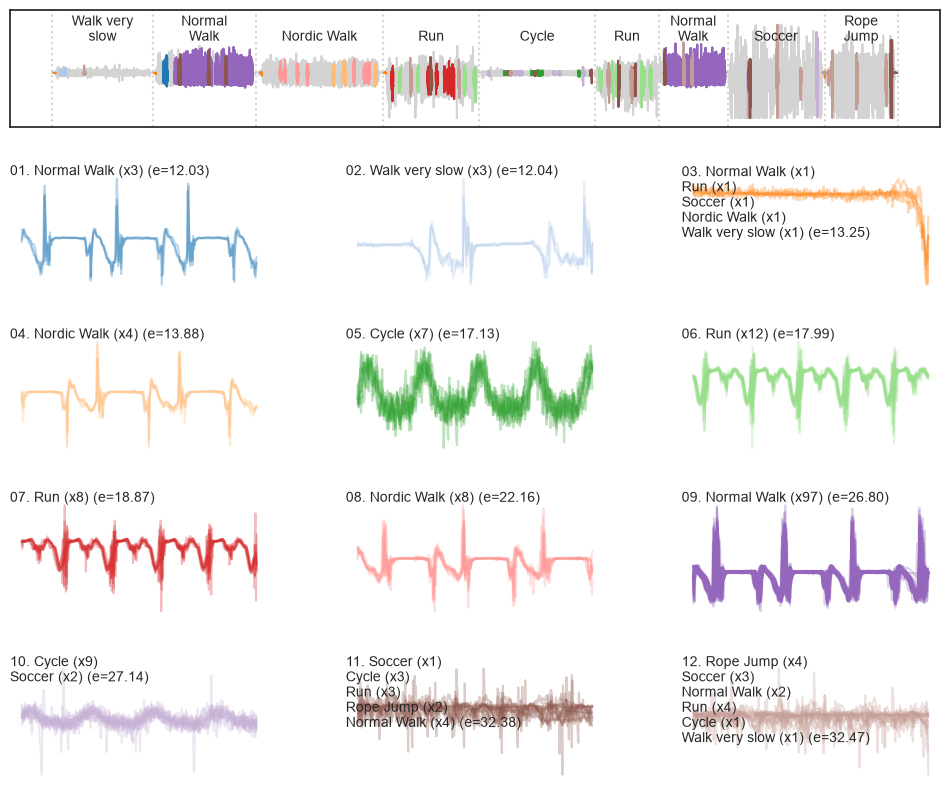

In [15]:
plot_topn(
    scampi_long_topn, 
    changepoints, 
    annotations, 
    fname=f"human-activity-w{scampi_long_topn.motif_length}.pdf"
) 

In [17]:
last_two = series[changepoints[-3]:]
k_max, motif_length, top_N = 100, 110, 3

scampi_last_two = SCAMPI(
    "Human Activity",
    last_two,
    n_jobs=-1,
    backend="scampi",
    verbose=False,
    scampi_delta=0.1
)


 
dists, candidates, elbow_points = scampi_last_two.fit_k_elbow(
    k_max=k_max,
    motif_length=motif_length,
    top_N=top_N,
    scampi_top_n_strategy="mask",
    plot_elbows=False,
    plot_motifs_as_grid=False,    
)


SCAMPI kwargs: delta=0.1, max_memory=2 GB, exact_refine=False, scampi_top_n_strategy=mask, unused={}


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 1.3162070909999999
	Time for Test 1.35094742
masked timestamps: 3282


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 1.272218877
	Time for Test 1.311985223
masked timestamps: 10065
	Time for Build 1.377383585
	Time for Test 1.331985513
masked timestamps: 16353


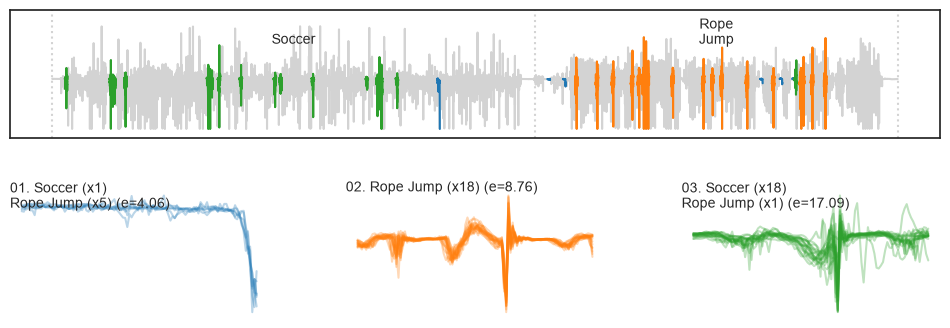

In [18]:
plot_topn(
    scampi_last_two, 
    changepoints=changepoints[-3:]-changepoints[-3], 
    annotations=annotations[-2:], 
    fname=f"human-activity-w{scampi_last_two.motif_length}-last-two.pdf"
)

In [19]:
def quantitative_evaluation(
    topn: SCAMPI,
    changepoints: np.array,
    annotations
):
    w = topn.motif_length
    section_motiflets = dict()
    
    for rank, elbows in enumerate(topn.elbow_points):
      if len(elbows) == 0:
          continue
    
      k = elbows[0]  # matches old motif_sets[elbow_points[-1]][0][0]
      hsm = np.asarray(topn.motiflets[k][rank]).squeeze()
      if hsm.size == 0:
          continue
    
      mlabels = dict()
      for t in hsm:
          t = int(t)
          segment = np.searchsorted(changepoints, t) - 1
          l = annotations[segment]
          mlabels[l] = mlabels.get(l, 0) + 1
    
      best_count, best_label = max((v, k) for k, v in mlabels.items())
    
      section = section_motiflets.get(best_label, [])
      section.extend(hsm)
      section_motiflets[best_label] = section
    
    results = []
    for section, motiflets in section_motiflets.items():
      total = 0
      covered = 0
      flags = np.zeros_like(topn.series)
    
      for t in motiflets:
          t = int(t)
          flags[t:t + w] = 1
    
      for l, (b, e) in zip(annotations, zip(changepoints[:-1], changepoints[1:])):
          if l == section:
              covered += flags[b:e].sum()
              total += e - b
    
      results.append(dict(section=section, total=total, covered=covered))
    
    results = pd.DataFrame(results)
    results["fraction"] = results["covered"] / results["total"]
    return results

In [20]:
quantitative_evaluation(scampi_topn, changepoints, annotations)

,section,total,covered,fraction
0,Normal\nWalk,35324,12046.0,0.341015
1,Nordic Walk,26234,6811.0,0.259625
2,Walk very\nslow,20657,7000.0,0.338868
3,Run,32797,7682.0,0.234229
4,Cycle,23864,1600.0,0.067047


In [21]:
quantitative_evaluation(scampi_long_topn, changepoints, annotations)

,section,total,covered,fraction
0,Normal\nWalk,35324,27780.0,0.786434
1,Run,32797,9359.0,0.285361
2,Walk very\nslow,20657,1405.0,0.068016
3,Cycle,23864,6016.0,0.252095
4,Nordic Walk,26234,4675.0,0.178204


In [22]:
quantitative_evaluation(scampi_last_two, changepoints, annotations)

,section,total,covered,fraction
0,Normal\nWalk,35324,2368.0,0.067037
1,Walk very\nslow,20657,1795.0,0.086895


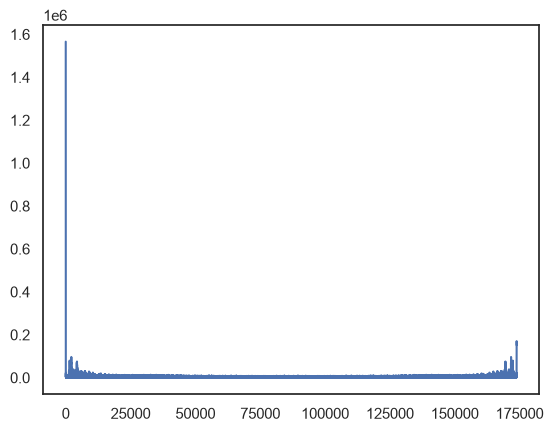

40

In [23]:
find_dominant_window_sizes(series)

dominant frequency 4.282979513700392 corresponding window 23.348232154769846


23

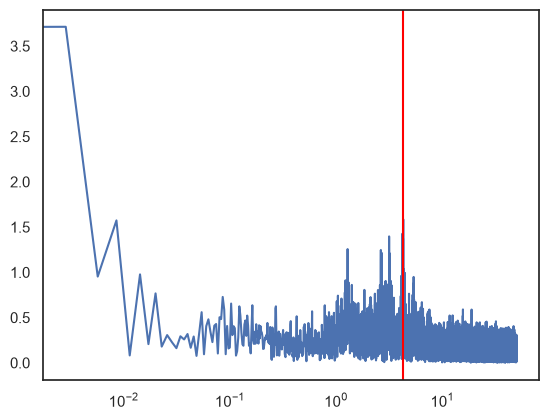

In [24]:
find_dominant_window_sizes2(series[changepoints[-3]:])

dominant frequency 1.2393961179007909 corresponding window 80.6844547563805
SCAMPI kwargs: delta=0.1, max_memory=2 GB, exact_refine=False, scampi_top_n_strategy=mask, unused={}


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 10.863295704
	Time for Test 6.289339452
masked timestamps: 13074


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 10.068904628
	Time for Test 14.883541128
masked timestamps: 23558
	Time for Build 11.191975946
	Time for Test 16.434220168
masked timestamps: 43905


...

	Time for Build 9.535463209
	Time for Test 14.857069455
masked timestamps: 132833
	Time for Build 8.363022499
	Time for Test 14.335527289
masked timestamps: 139424


[src/timeseries.rs:781:9] fft_length = 16384
[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 8.204984919
	Time for Test 14.106943887
masked timestamps: 142598
	Time for Build 8.773138944
	Time for Test 14.350614345
masked timestamps: 150556


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 8.326988997
	Time for Test 15.046675506
masked timestamps: 157934


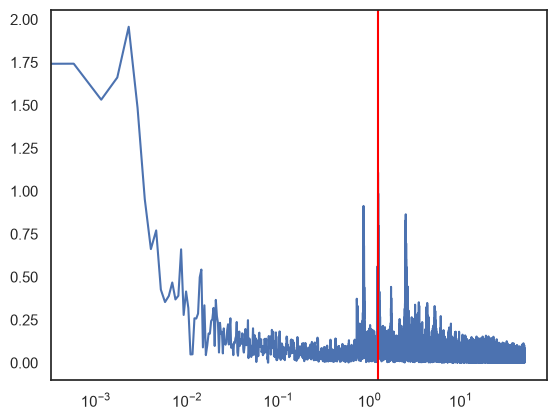

In [25]:
motif_length = 4 * find_dominant_window_sizes2(series)

long_topn_alt = SCAMPI(
    "Human Activity",
    series,
    n_jobs=-1,
    backend="scampi",
    verbose=False,
    scampi_delta=0.1,
)

dists, candidates, elbow_points = long_topn_alt.fit_k_elbow(
    k_max=100,
    motif_length=motif_length,
    top_N=12,
    scampi_top_n_strategy="mask",
    plot_elbows=False,
    plot_motifs_as_grid=False,
)


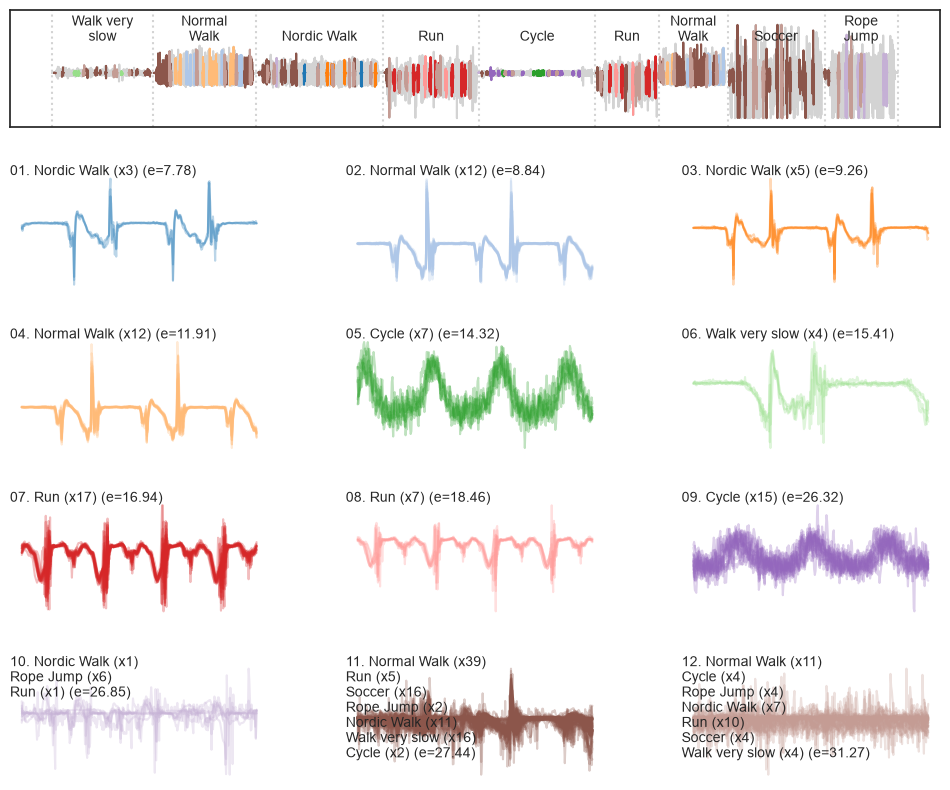

In [26]:
plot_topn(
    long_topn_alt, 
    changepoints, 
    annotations, 
    fname=f"human-activity-w{long_topn_alt.motif_length}.pdf"
) 

dominant frequency 4.282979513700392 corresponding window 23.348232154769846
SCAMPI kwargs: delta=0.1, max_memory=2 GB, exact_refine=False, scampi_top_n_strategy=mask, unused={}


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.814941079
	Time for Test 1.23151583
masked timestamps: 1035


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.857298876
	Time for Test 1.250461711
masked timestamps: 17544


[src/timeseries.rs:781:9] fft_length = 16384


	Time for Build 0.939008741
	Time for Test 0.743394999
masked timestamps: 24825


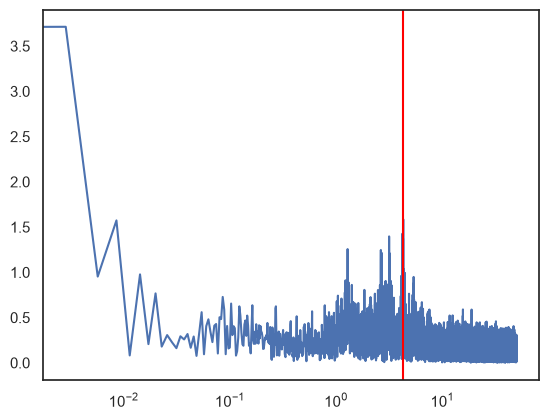

In [27]:
last_two_alt_topn = SCAMPI(
    "Human Activity",
    last_two,
    n_jobs=-1,
    backend="scampi",
    verbose=False,
    scampi_delta=0.1,
)

dists, candidates, elbow_points = last_two_alt_topn.fit_k_elbow(
    k_max=100,
    motif_length=3 * find_dominant_window_sizes2(last_two),
    top_N=3,
    scampi_top_n_strategy="mask",
    plot_elbows=False,
    plot_motifs_as_grid=False,
)



In [28]:
plot_topn(last_two_alt_topn, changepoints=changepoints[-3:]-changepoints[-3], annotations=annotations[-2:], fname=f"human-activity-w{last_two_alt_topn.window_size}-last-two.pdf")

AttributeError: 'SCAMPI' object has no attribute 'window_size'

In [ ]:
5*find_dominant_window_sizes2(series)

In [ ]:
5*find_dominant_window_sizes2(series[changepoints[-3]:])